<a href="https://colab.research.google.com/github/i-malur/bootcamp-dados-desafio-python-3/blob/main/%5BMALU_RESPOSTAS%5D_Challenge_Probabilidade_e_Amostragem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Preparando ambiente

In [69]:
# bibliotecas de base
import pandas as pd
import numpy as np

# bibliotecas para visualização dos dados
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# bibliotecas auxiliares
from collections import Counter

# biblioteca para estatística
import scipy.stats as stat

In [70]:
url = 'https://raw.githubusercontent.com/i-malur/bootcamp-dados-desafio-python-3/refs/heads/main/clientes.csv'
df = pd.read_csv(url)

# 1. Desafio:
Suponha que você trabalha em uma empresa de streaming e, com as mudanças no
mercado, a equipe de marketing suspeita que o perfil dos clientes que cancelaram a assinatura mudou. Eles pediram sua ajuda para entender:

1. Se o perfil dos clientes que cancelam hoje é diferente do perfil dos clientes
que cancelaram anteriormente.  
Dica: Fazer um comparativo dos clientes que cancelaram nos últimos 6 meses com os que cancelaram a mais de 24 meses.

2. Quais são as principais diferenças entre os perfis, para que possam criar
estratégias mais eficazes de retenção. Para isso, eles fornecem a base de
dados clientes.csv, que contém informações anonimizadas sobre os clientes
ao longo do tempo.


# 2. Dicas:

1. Analise a distribuição de idade, tempo de assinatura, frequência de uso e região
dos clientes que cancelaram e dos novos clientes no período de 24 meses.
2. Plote gráficos para identificar padrões nos clientes que mantêm e cancelam a
assinatura.
3. Utilize testes estatísticos para verificar se há uma relação significativa entre
tempo de assinatura e taxa de cancelamento.
4. Suponha agora que os dados recebidos são somente uma amostra da sua
população total de clientes. Suponha que a sua "população" de clientes
verdadeira é de 100000. Qual o tamanho da amostra necessária para chegarmos a
conclusões com 95% de confiança e 2% de margem de erro? A base informada é
suficiente? E com uma margem de erro de 10%?

# Informações gerais do Dataframe

In [71]:
df.head(5)

,cliente_id,idade,tempo_assinatura_meses,frequencia_uso_mensal,regiao,mensalidade,cancelou
0,1,56,30,27,Centro-Oeste,96.03,1
1,2,69,11,2,Norte,91.22,0
2,3,46,58,21,Sul,56.45,0
3,4,32,55,1,Norte,69.61,0
4,5,60,28,28,Sul,42.19,0


In [72]:
print('tipos de dados de cada coluna:')
df.info()

print('-'*90)

print('verificando valores vazios nas colunas')
print(df.isnull().sum())

print('-'*90)
print('linhas e colunas do dataframe')
print(df.shape)

tipos de dados de cada coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cliente_id              200 non-null    int64  
 1   idade                   200 non-null    int64  
 2   tempo_assinatura_meses  200 non-null    int64  
 3   frequencia_uso_mensal   200 non-null    int64  
 4   regiao                  200 non-null    object 
 5   mensalidade             200 non-null    float64
 6   cancelou                200 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 11.1+ KB
------------------------------------------------------------------------------------------
verificando valores vazios nas colunas
cliente_id                0
idade                     0
tempo_assinatura_meses    0
frequencia_uso_mensal     0
regiao                    0
mensalidade               0
cancelou                  0

# O que precisamos entender?

Se o perfil dos clientes que cancelam hoje é diferente do perfil dos clientes que cancelaram anteriormente.  
Dica: Fazer um comparativo dos clientes que cancelaram nos últimos 6 meses com os que cancelaram a mais de 24 meses.

# 1. Analise a distribuição de idade, tempo de assinatura, frequência de uso e região dos clientes que cancelaram e dos novos clientes no período de 24 meses.


## Criando grupos

In [73]:
df_cancelados_6meses = df[(df['cancelou'] == 1) & (df['tempo_assinatura_meses'] <= 6)]

df_cancelados_6meses.head()

,cliente_id,idade,tempo_assinatura_meses,frequencia_uso_mensal,regiao,mensalidade,cancelou
17,18,20,6,28,Norte,33.01,1
60,61,37,2,1,Centro-Oeste,61.62,1
79,80,71,6,4,Sudeste,55.00,1
90,91,32,3,15,Centro-Oeste,59.37,1
108,109,32,1,15,Centro-Oeste,73.40,1


In [74]:
df_cancelados_6meses.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 17 to 181
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cliente_id              9 non-null      int64  
 1   idade                   9 non-null      int64  
 2   tempo_assinatura_meses  9 non-null      int64  
 3   frequencia_uso_mensal   9 non-null      int64  
 4   regiao                  9 non-null      object 
 5   mensalidade             9 non-null      float64
 6   cancelou                9 non-null      int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 576.0+ bytes


In [75]:
df_cancelados_24meses = df[(df['cancelou'] == 1) & (df['tempo_assinatura_meses'] > 24)]

df_cancelados_24meses.head()

,cliente_id,idade,tempo_assinatura_meses,frequencia_uso_mensal,regiao,mensalidade,cancelou
0,1,56,30,27,Centro-Oeste,96.03,1
19,20,70,27,14,Nordeste,85.80,1
22,23,61,33,3,Sudeste,69.07,1
28,29,29,59,17,Nordeste,50.12,1
29,30,39,54,14,Sudeste,84.84,1


In [76]:
df_cancelados_24meses.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 0 to 196
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cliente_id              32 non-null     int64  
 1   idade                   32 non-null     int64  
 2   tempo_assinatura_meses  32 non-null     int64  
 3   frequencia_uso_mensal   32 non-null     int64  
 4   regiao                  32 non-null     object 
 5   mensalidade             32 non-null     float64
 6   cancelou                32 non-null     int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 2.0+ KB


## Variáveis numéricas:

In [77]:
colunas = ['idade', 'tempo_assinatura_meses', 'frequencia_uso_mensal', 'mensalidade']

metricas = pd.DataFrame({
    'Média (Assinantes com até 6 meses)': df_cancelados_6meses[colunas].mean().round(),
    'Mediana (Assinantes com até 6 mesess)': df_cancelados_6meses[colunas].median().round(),
    'Média (Assinantes com mais de 24 meses)': df_cancelados_24meses[colunas].mean().round(),
    'Mediana (Assinantes com mais de 24 meses)': df_cancelados_24meses[colunas].median().round()
})

metricas

,Média (Assinantes com até 6 meses),Mediana (Assinantes com até 6 mesess),Média (Assinantes com mais de 24 meses),Mediana (Assinantes com mais de 24 meses)
idade,41.0,37.0,44.0,44.0
tempo_assinatura_meses,3.0,3.0,43.0,47.0
frequencia_uso_mensal,12.0,7.0,16.0,16.0
mensalidade,60.0,59.0,61.0,58.0


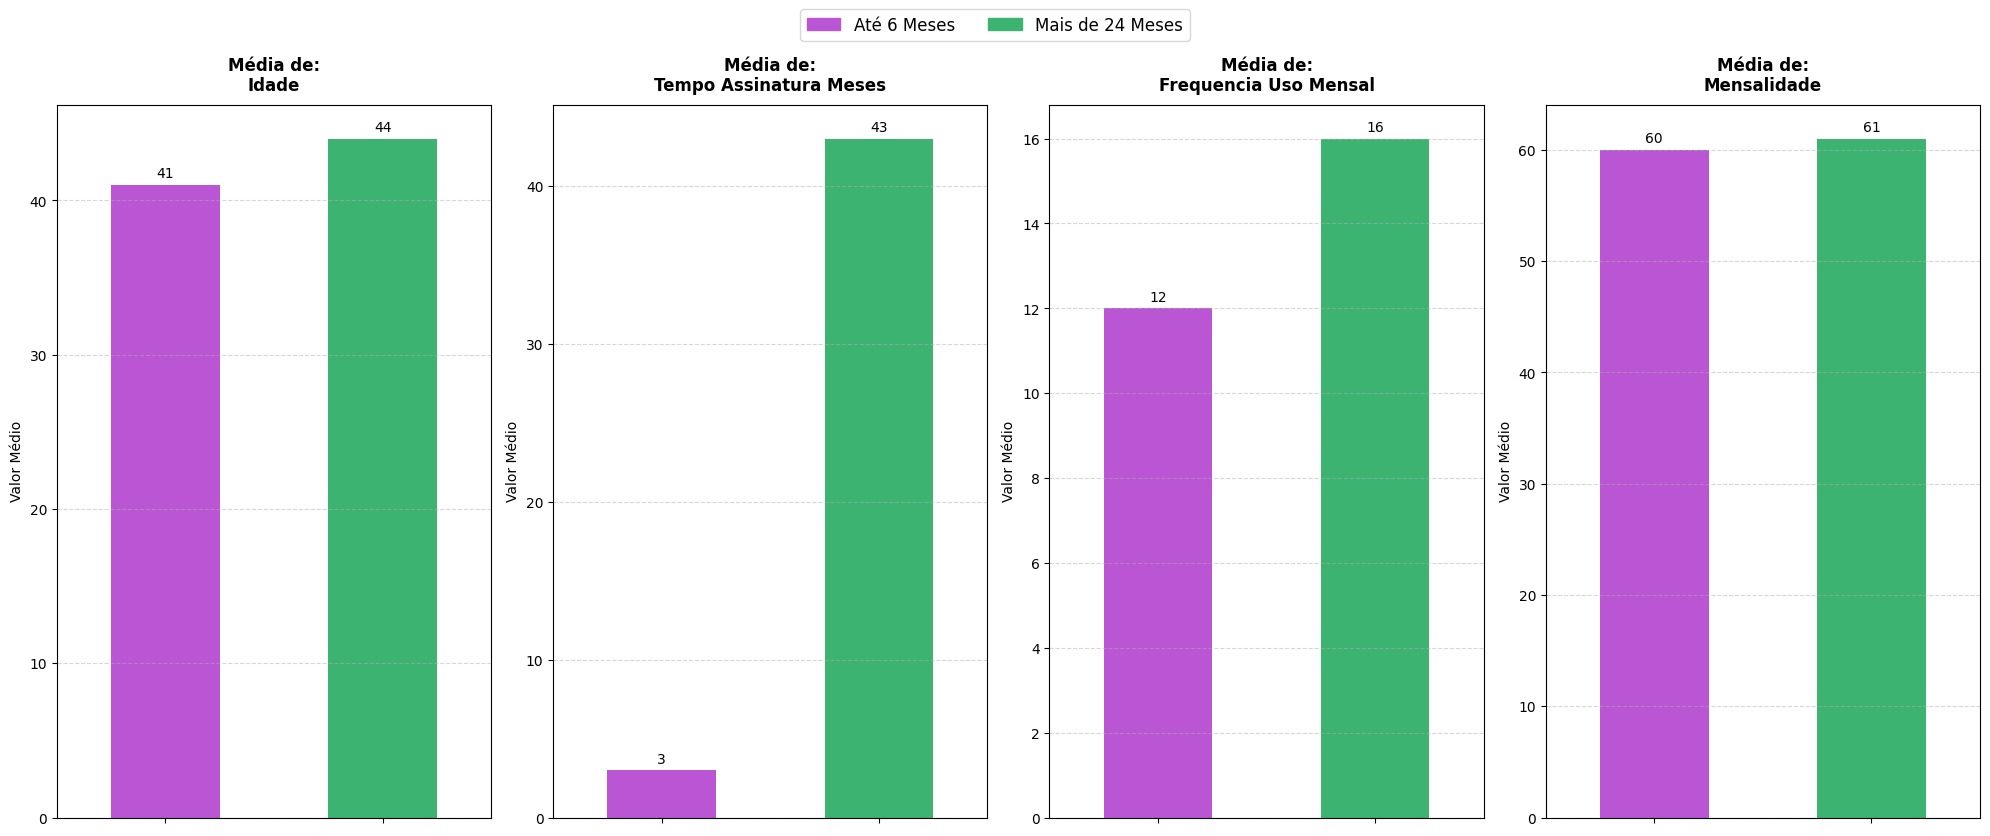

In [78]:
df_medias = metricas.filter(like='Média')

fig, axes = plt.subplots(1, 4, figsize=(20, 8))

cor_6meses = '#BA55D3'
cor_24meses = '#3CB371'
cores = [cor_6meses, cor_24meses]

for (variavel, dados_linha), ax in zip(df_medias.iterrows(), axes):

    dados_linha.plot(kind='bar', color=cores, width=0.5, ax=ax)

    titulo_limpo = variavel.replace('_', ' ').title()
    ax.set_title(f'Média de:\n{titulo_limpo}', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Valor Médio', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    ax.set_xticklabels([]) # limpa o eixo X, tirando textos

    # adiciona os valores no topo das barras
    for i in ax.containers:
        ax.bar_label(i, padding=3, fontsize=10)


# criação de legendas acima dos gráficos
legenda_6meses = mpatches.Patch(color=cor_6meses, label='Até 6 Meses')
legenda_24meses = mpatches.Patch(color=cor_24meses, label='Mais de 24 Meses')
fig.legend(handles=[legenda_6meses, legenda_24meses], loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=12)

plt.tight_layout()
plt.show()


Verificamos que:
* A média de idade das pessoas que eram assinantes em, no máximo 6 meses, 41 anos Já a média de idade das pessoas que eram assinantes a mais de 24 meses, 44 anos.
* A média tempo de assinatura dos clientes em até 6 meses é de 3 meses e com mais de 24 meses é de 43 meses.
* A média do uso mensal de clientes que eram assinantes em, no máximo 6 meses, é de 12 vezes no mês. Já a média dos clientes que tinham mais de 24 meses é 16 vezes por mês.
* O valor médio de mensalidade que os clientes que eram assinantes em, no máximo 6 meses é de RS 60. Já a média dos clientes que tinham mais de 24 meses é de RS 61.


Observação:
* O total de clientes que tinham em tempo de assinatura em até 6 meses e cancelaram é de 9 registros.

/tmp/ipykernel_7732/3057667276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cancelados_6meses['Grupo'] = 'Até 6 meses'
/tmp/ipykernel_7732/3057667276.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cancelados_24meses['Grupo'] = 'Mais de 24 meses'
/tmp/ipykernel_7732/3057667276.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_compa

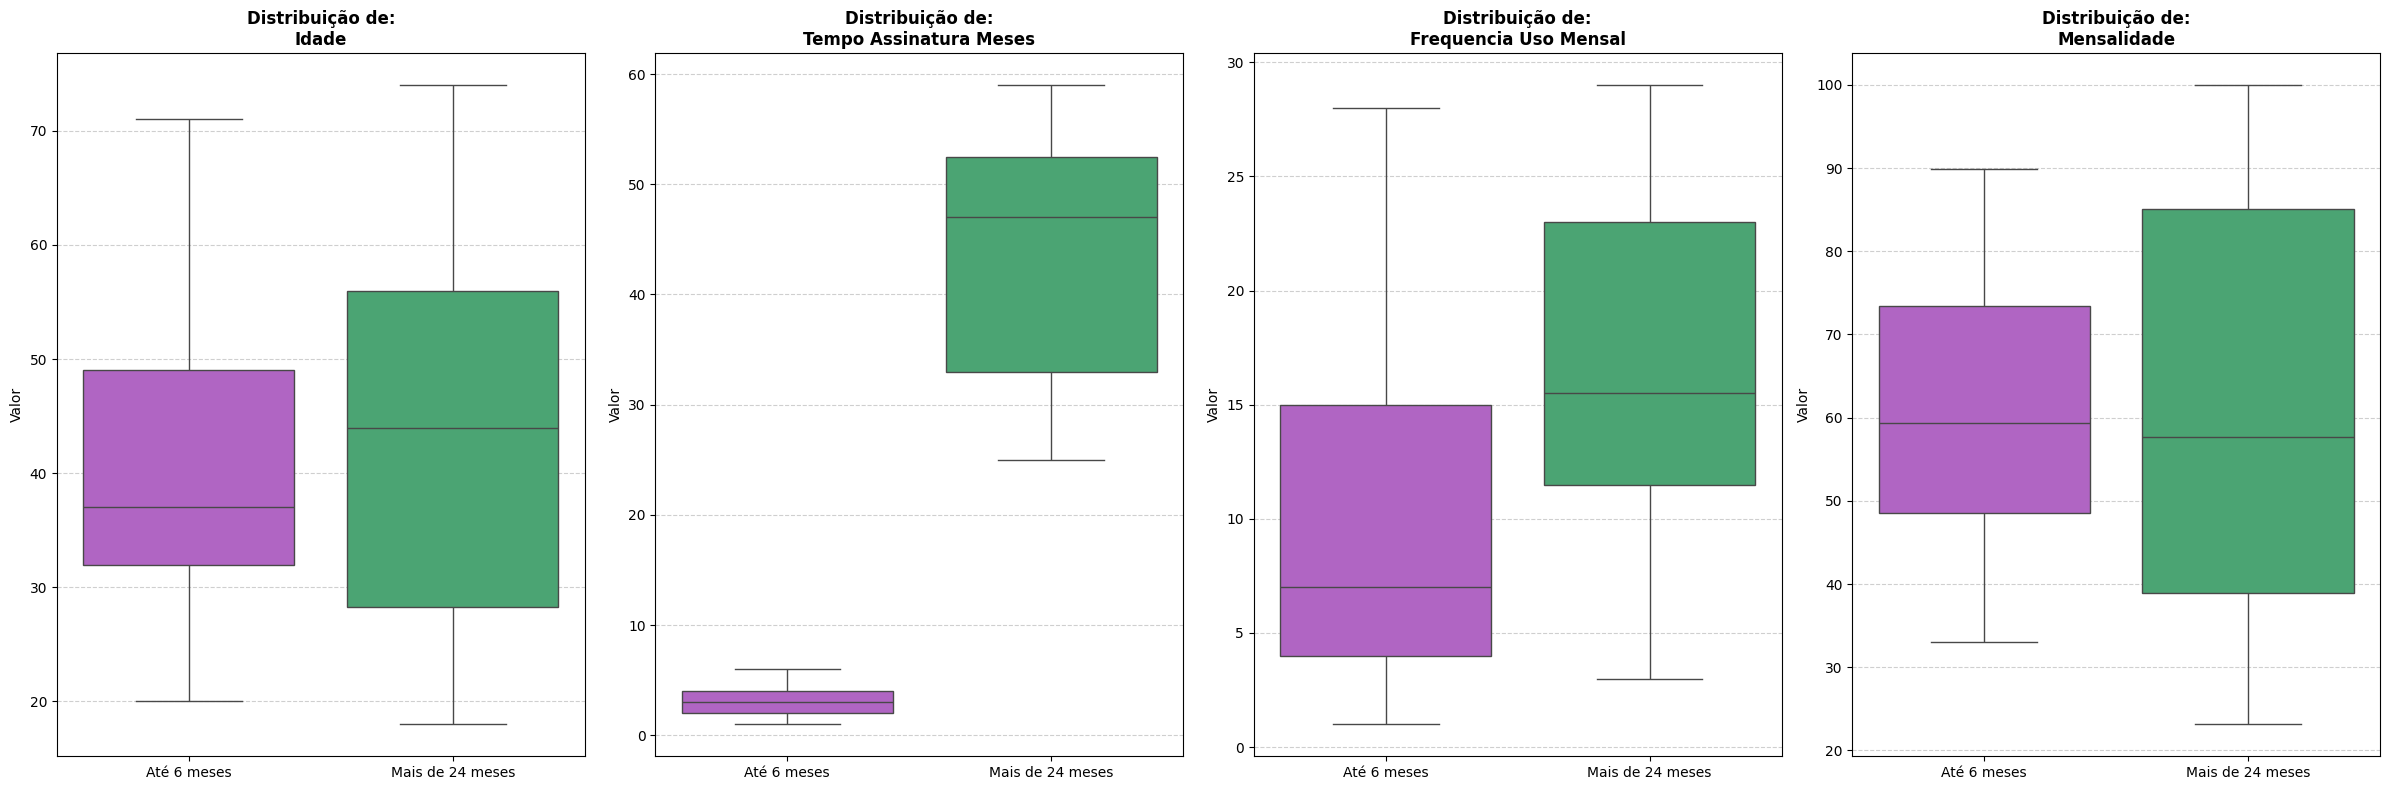

In [79]:
df_cancelados_6meses['Grupo'] = 'Até 6 meses'
df_cancelados_24meses['Grupo'] = 'Mais de 24 meses'

df_comparacao = pd.concat([df_cancelados_6meses, df_cancelados_24meses])

colunas = ['idade', 'tempo_assinatura_meses', 'frequencia_uso_mensal', 'mensalidade']

fig, axes = plt.subplots(1, 4, figsize=(24, 8))

for i, coluna in enumerate(colunas):
  sns.boxplot(data=df_comparacao, x='Grupo', y=coluna, palette=['#BA55D3', '#3CB371'], ax=axes[i])

  axes[i].set_title(f'Distribuição de:\n{coluna.replace("_", " ").title()}', fontsize=12, fontweight='bold')
  axes[i].set_ylabel('Valor')
  axes[i].set_xlabel('')
  axes[i].yaxis.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Variáveis categóricas

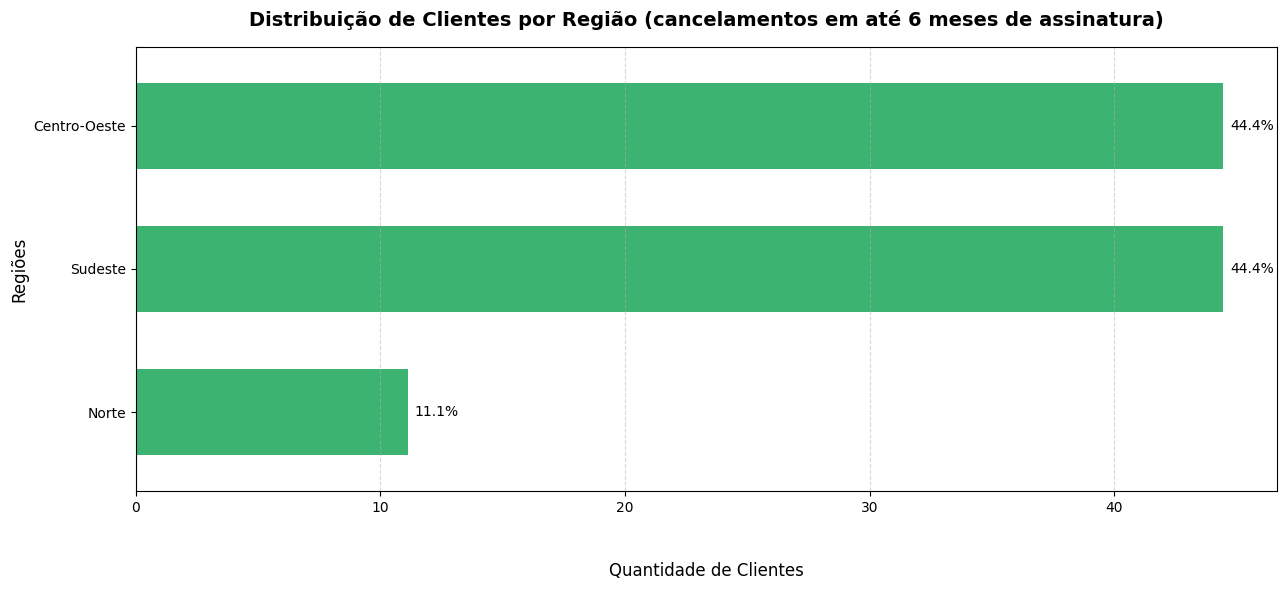

In [80]:
contagem_regioes = (df_cancelados_6meses['regiao'].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(13, 6))

ax = contagem_regioes.plot(kind='barh', color='#3CB371', width=0.6)
ax.invert_yaxis()

plt.title('Distribuição de Clientes por Região (cancelamentos em até 6 meses de assinatura)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('\n\nQuantidade de Clientes', fontsize=12)
plt.ylabel('Regiões', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, fmt='{:.1f}%')

plt.tight_layout()
plt.show()


* Como só temos 9 registros de clientes que cancelaram com <=6 meses de assinatura, é dificil analisar a distribuição de cancelamentos por região, dado que basicamente os 9 clientes que cancelaram com <= 6 meses são das regiões Centro-Oeste e Sudeste.

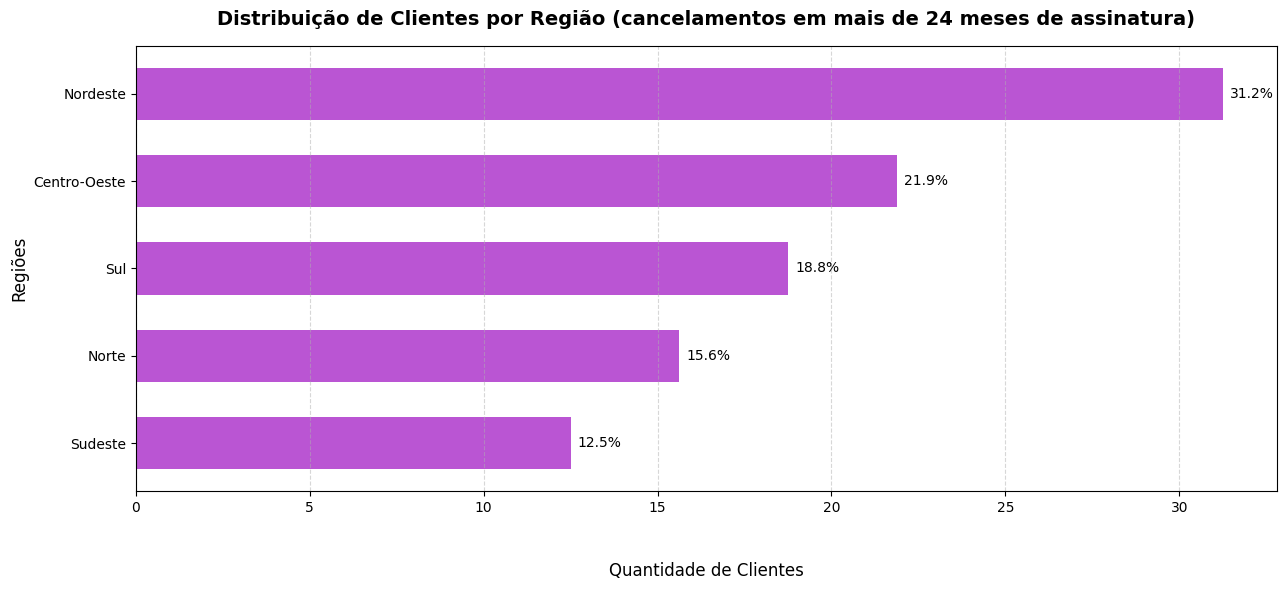

In [81]:
contagem_regioes = (df_cancelados_24meses['regiao'].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(13, 6))

ax = contagem_regioes.plot(kind='barh', color='#BA55D3', width=0.6)
ax.invert_yaxis()

plt.title('Distribuição de Clientes por Região (cancelamentos em mais de 24 meses de assinatura)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('\n\nQuantidade de Clientes', fontsize=12)
plt.ylabel('Regiões', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, fmt='{:.1f}%')

plt.tight_layout()
plt.show()


* A maior concentração dos clientes que cancelaram o plano com mais de 24 meses de assinatura está na região Nordeste, com 31.25%. Ou seja. Clientes do Nordeste cancelam o plano mais tardiamente.

1. Clientes que cancelam nos primeiros seis meses utilizam menos a plataforma, indicando que o baixo engajamento pode estar relacionado ao cancelamento precoce.
2. Os cancelamentos após mais de 24 meses apresentam maior concentração de clientes da região Nordeste na amostra analisada.
3. Variáveis de Idade e mensalidade não apresentaram diferenças relevantes entre os grupos, sugerindo que essas características não são bons indicadores para distinguir cancelamentos precoces e tardios.

# 2. Plote gráficos para identificar padrões nos clientes que mantêm e cancelam a assinatura.

* Separando os grupos de cancelados e não cancelados
* Nós temos 56 registros de cancelados e 144 não cancelados

In [82]:
df_cancelados = df[df['cancelou'] == 1]

df_cancelados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 0 to 196
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cliente_id              56 non-null     int64  
 1   idade                   56 non-null     int64  
 2   tempo_assinatura_meses  56 non-null     int64  
 3   frequencia_uso_mensal   56 non-null     int64  
 4   regiao                  56 non-null     object 
 5   mensalidade             56 non-null     float64
 6   cancelou                56 non-null     int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 3.5+ KB


In [83]:
colunas = ['idade', 'tempo_assinatura_meses', 'frequencia_uso_mensal', 'mensalidade']

metricas_cancelados = pd.DataFrame({
    'Média': df_cancelados[colunas].mean().round(),
    'Mediana': df_cancelados[colunas].median().round()
})

metricas_cancelados

,Média,Mediana
idade,43.0,42.0
tempo_assinatura_meses,30.0,30.0
frequencia_uso_mensal,16.0,15.0
mensalidade,57.0,54.0


In [84]:
df_nao_cancelados = df[df['cancelou'] == 0]

df_nao_cancelados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 1 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cliente_id              144 non-null    int64  
 1   idade                   144 non-null    int64  
 2   tempo_assinatura_meses  144 non-null    int64  
 3   frequencia_uso_mensal   144 non-null    int64  
 4   regiao                  144 non-null    object 
 5   mensalidade             144 non-null    float64
 6   cancelou                144 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 9.0+ KB


In [85]:
metricas_nao_cancelados = pd.DataFrame({
    'Média': df_nao_cancelados[colunas].mean().round(),
    'Mediana': df_nao_cancelados[colunas].median().round()
})

metricas_nao_cancelados

,Média,Mediana
idade,46.0,46.0
tempo_assinatura_meses,31.0,33.0
frequencia_uso_mensal,16.0,17.0
mensalidade,60.0,60.0


/tmp/ipykernel_7732/44529315.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7732/44529315.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7732/44529315.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7732/44529315.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


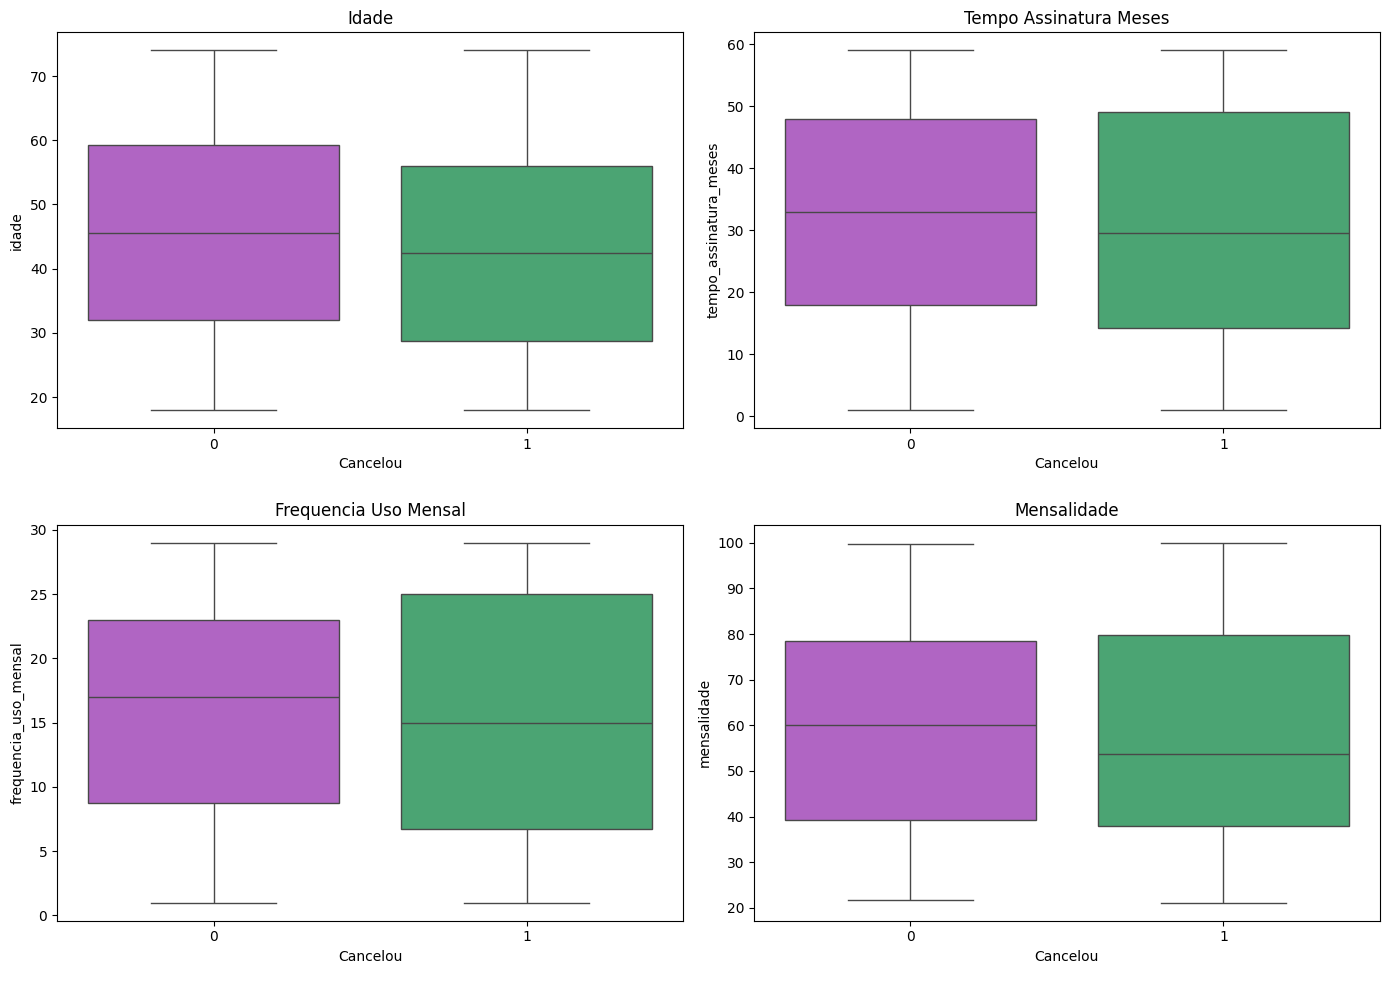

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for i, coluna in enumerate(colunas):

    sns.boxplot(
        data=df,
        x='cancelou',
        y=coluna,
        palette=['#BA55D3', '#3CB371'],
        ax=axes[i]
    )

    axes[i].set_title(coluna.replace('_', ' ').title())
    axes[i].set_xlabel('Cancelou\n')
    axes[i].set_ylabel(coluna)

plt.tight_layout()
plt.show()

In [87]:
medias = pd.DataFrame({
    'Cancelados': metricas_cancelados['Média'],
    'Não cancelados': metricas_nao_cancelados['Média']
})

medias

,Cancelados,Não cancelados
idade,43.0,46.0
tempo_assinatura_meses,30.0,31.0
frequencia_uso_mensal,16.0,16.0
mensalidade,57.0,60.0


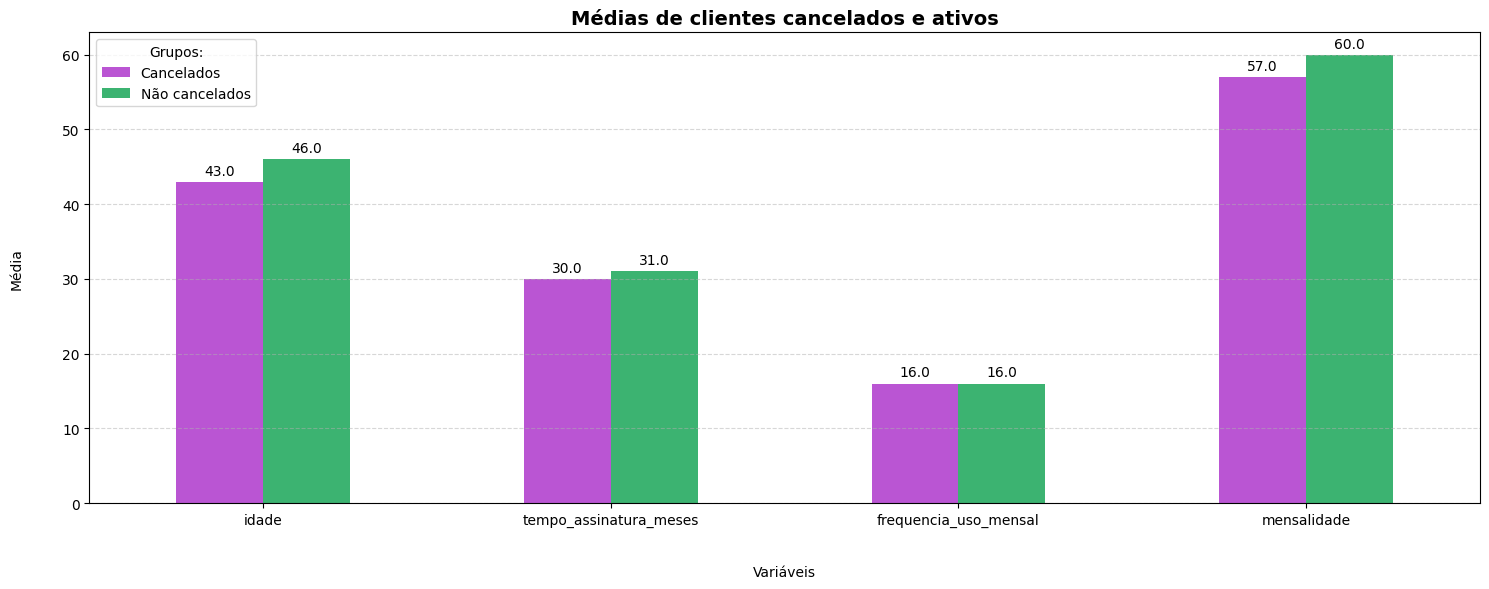

In [88]:
ax = medias.plot(
    kind='bar',
    figsize=(15,6),
    color=['#BA55D3', '#3CB371']
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3,
        fontsize=10
    )

plt.title('Médias de clientes cancelados e ativos',
          fontsize=14,
          fontweight='bold')

plt.xlabel('\n\nVariáveis')
plt.ylabel('Média\n\n')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title='Grupos:')

plt.tight_layout()
plt.show()

Observações:

* Os clientes que mantiveram a assinatura apresentam idade média ligeiramente superior à dos clientes que cancelaram. Entretanto, a diferença observada é pequena.
* O tempo de assinatura entre os 2 grupos é quase igual. Fato curioso, pois, no cenário anterior, a diferença da frequência era maior.

# Utilize testes estatísticos para verificar se há uma relação significativa entre tempo de assinatura e taxa de cancelamento.


As variáveis são:

tempo_assinatura_meses → numérica  
cancelou → binária (0 = não, 1 = sim)

Então queremos saber:
O tempo de assinatura é diferente entre quem cancela e quem não cancela?

In [89]:
df['cancelou'].value_counts(normalize=True).mul(100).round(2) # 28% dos clientes cancelaram

,proportion
cancelou,
0,72.0
1,28.0


In [90]:
cancelados = df[df['cancelou'] == 1]['tempo_assinatura_meses']
nao_cancelados = df[df['cancelou'] == 0]['tempo_assinatura_meses']

**Teste de Normalidade (Shapiro-Wilk)**

Objetivo:
* Verificar se a variável tempo_assinatura_meses segue distribuição normal nos grupos de clientes cancelados e não cancelados.

Hipóteses:
* H₀: Os dados seguem distribuição normal.  
* H₁: Os dados não seguem distribuição normal.

Resultado:

* Ambos os grupos apresentaram p-value < 0,05, indicando rejeição da hipótese nula. Portanto, os dados não seguem distribuição normal e será utilizado um teste não paramétrico para comparar os grupos.

In [91]:
# verificando se os grupos seguem distribuição normal
from scipy.stats import shapiro

In [92]:
def interpreta_shapiro(nome, grupo):
  stat, p = shapiro(grupo)

  print(f'Grupo: {nome}')
  print(f'Estatística: {stat:.4f}')
  print(f'p-value: {p:.4f}')

  if p > 0.05:
      print('Distribuição aproximadamente normal.\n')
  else:
      print('Distribuição não normal.\n')

In [93]:
interpreta_shapiro('Cancelados', cancelados)
interpreta_shapiro('Não cancelados', nao_cancelados)

Grupo: Cancelados
Estatística: 0.9317
p-value: 0.0035
Distribuição não normal.

Grupo: Não cancelados
Estatística: 0.9530
p-value: 0.0001
Distribuição não normal.



**Teste Mann-Whitney**

Objetivo:

* Verificar se o tempo de assinatura difere entre clientes que cancelaram e clientes que permaneceram ativos.

Hipóteses:

* H₀: A distribuição do tempo de assinatura é a mesma para os dois grupos.  
* H₁: A distribuição do tempo de assinatura é diferente entre os grupos.

Nível de significância:

* Adotando um nível de significância de 5% (α = 0,05).

Comparação:
```
p-value = 0,5278
0,5278 > 0,05
```

Logo:

Não rejeitamos a hipótese nula (H₀).

In [94]:
from scipy.stats import mannwhitneyu

In [95]:
estatistica, p = mannwhitneyu(
    cancelados,
    nao_cancelados,
    alternative='two-sided'
)

print(f'Estatística U: {estatistica:.2f}')
print(f'p-value: {p:.4f}')

Estatística U: 3799.50
p-value: 0.5278


Conclusão: O teste de Mann-Whitney foi utilizado para comparar o tempo de assinatura entre clientes que cancelaram e clientes que permaneceram ativos, uma vez que os dados não apresentaram distribuição normal segundo o teste de Shapiro-Wilk. O resultado (U = 3799,50; p = 0,5278) indica que não há evidências estatisticamente significativas de diferença no tempo de assinatura entre os dois grupos, considerando um nível de significância de 5%.

Traduzindo: Embora os clientes que cancelaram e os que permaneceram apresentem pequenas diferenças nas médias de tempo de assinatura, essas diferenças não foram estatisticamente significativas. Isso sugere que, na amostra analisada, o tempo de assinatura, por si só, não é um bom indicador para distinguir clientes que cancelam daqueles que permanecem ativos.

**Teste Qui-Quadrado**

Objetivo

* Verificar se existe associação entre a faixa de tempo de assinatura e o cancelamento da assinatura.

Hipótese nula (H₀)

* Não existe associação entre as variáveis. Ou seja, o cancelamento é independente da faixa de tempo de assinatura.

Hipótese alternativa (H₁)
* Existe associação entre as variáveis.

In [96]:
faixas = [0, 6, 24, float('inf')]
rotulos = ['Até 6 meses', '7 a 24 meses', 'Acima de 24 meses']

df['faixa_tempo'] = pd.cut(
    df['tempo_assinatura_meses'],
    bins=faixas,
    labels=rotulos
)

In [97]:
tabela = pd.crosstab(
    df['faixa_tempo'],
    df['cancelou']
)

tabela

cancelou,0,1
faixa_tempo,,
Até 6 meses,15,9
7 a 24 meses,37,15
Acima de 24 meses,92,32


In [98]:
from scipy.stats import chi2_contingency

In [99]:
qui2, p, gl, esperado = chi2_contingency(tabela)
print(f'Qui-quadrado: {qui2:.4f}')
print(f'p-value: {p:.4f}')
print(f'Graus de liberdade: {gl}')

Qui-quadrado: 1.3888
p-value: 0.4994
Graus de liberdade: 2


In [100]:
# tabela que mostra os valores esperados caso não existisse nenhuma associação entre as variáveis.
esperado_df = pd.DataFrame(
    esperado,
    index=tabela.index,
    columns=tabela.columns
)

esperado_df

cancelou,0,1
faixa_tempo,,
Até 6 meses,17.28,6.72
7 a 24 meses,37.44,14.56
Acima de 24 meses,89.28,34.72


Conclusão: Foi aplicado o teste do Qui-quadrado para verificar se existe associação entre a faixa de tempo de assinatura e o cancelamento da assinatura. O teste resultou em χ² = 1,3888, com p-value = 0,4994. Como o valor de p é superior ao nível de significância de 5%, não há evidências estatísticas suficientes para afirmar que existe associação entre as variáveis.  

Traduzindo: Os resultados sugerem que, na amostra analisada, a faixa de tempo de assinatura não está associada ao cancelamento. Dessa forma, clientes com diferentes tempos de assinatura apresentaram comportamentos de cancelamento semelhantes, indicando que outras variáveis podem exercer maior influência na decisão de cancelar o serviço.

In [101]:
print("Frequências observadas")
display(tabela)

print('\n\n')
print('-'*90)

print("\n\nFrequências esperadas")
display(esperado_df)

Frequências observadas


cancelou,0,1
faixa_tempo,,
Até 6 meses,15,9
7 a 24 meses,37,15
Acima de 24 meses,92,32





------------------------------------------------------------------------------------------


Frequências esperadas


cancelou,0,1
faixa_tempo,,
Até 6 meses,17.28,6.72
7 a 24 meses,37.44,14.56
Acima de 24 meses,89.28,34.72


## Outros testes estatísticos podemos realizar?


### Idade x Cancelamento


Objetivo:

* Verificar se existe diferença significativa na idade entre clientes que cancelaram a assinatura e clientes que permaneceram ativos.

Hipóteses:
* H₀: A distribuição da idade é a mesma entre clientes cancelados e não cancelados.
* H₁: A distribuição da idade é diferente.

In [102]:
cancelados_idade = df[df['cancelou'] == 1]['idade']
nao_cancelados_idade = df[df['cancelou'] == 0]['idade']

In [103]:
# usando o Shapiro-Wilk para verificar a distribuição dos dados
interpreta_shapiro("Cancelados", cancelados_idade)
interpreta_shapiro("Não cancelados", nao_cancelados_idade)

Grupo: Cancelados
Estatística: 0.9461
p-value: 0.0142
Distribuição não normal.

Grupo: Não cancelados
Estatística: 0.9580
p-value: 0.0002
Distribuição não normal.



Foi aplicado o teste de Shapiro-Wilk para verificar a normalidade da variável idade entre clientes cancelados e não cancelados. Em ambos os grupos, os valores de p foram inferiores a 0,05 (cancelados: p = 0,0142; não cancelados: p = 0,0002), indicando que a distribuição da idade não é normal. Dessa forma, optou-se pela utilização do teste não paramétrico de Mann-Whitney para comparar os grupos.

In [104]:
estatistica, p = mannwhitneyu(
    cancelados_idade,
    nao_cancelados_idade,
    alternative='two-sided'
)

print(f'Estatística U: {estatistica:.2f}')
print(f'p-value: {p:.4f}')

Estatística U: 3640.50
p-value: 0.2872


Após verificar que a variável idade não seguia distribuição normal em ambos os grupos pelo teste de Shapiro-Wilk, foi aplicado o teste não paramétrico de Mann-Whitney. O resultado (U = 3640,50; p = 0,2872) indica que não há evidências estatísticas suficientes para afirmar que existe diferença significativa na idade entre clientes que cancelaram e clientes que permaneceram ativos.

Ou seja: Embora os clientes que permaneceram ativos apresentem idade média ligeiramente superior (46 anos) em comparação aos clientes que cancelaram (43 anos), essa diferença não foi estatisticamente significativa. Assim, a idade, isoladamente, não se mostrou um fator determinante para explicar o cancelamento da assinatura.

### Região x Cancelamento

Objetivos:

* Analisar a relação de cancelamento vs região onde o cliente mora.


Hipóteses:

* H₀ (hipótese nula): Região e Cancelamento são independentes (a região não influencia o cancelamento).
* H₁ (hipótese alternativa): Região e Cancelamento possuem associação (existe relação entre região e cancelamento).

In [105]:
# tabela de contingência
pd.crosstab(df["regiao"], df["cancelou"])

cancelou,0,1
regiao,,
Centro-Oeste,35,12
Nordeste,20,15
Norte,32,9
Sudeste,29,12
Sul,28,8


In [106]:
from scipy.stats import chi2_contingency

tabela = pd.crosstab(df["regiao"], df["cancelou"])

chi2, p, gl, esperado = chi2_contingency(tabela)

print("Qui-quadrado:", chi2.round(4))
print("p-valor:", p.round(4))

Qui-quadrado: 5.3471
p-valor: 0.2535


O teste Qui-quadrado de independência foi aplicado para avaliar a relação entre Região e Cancelamento. O resultado apresentou χ² = 5,3471 e p-valor = 0,2535. Como o p-valor é superior ao nível de significância de 5%, não foi identificada associação estatisticamente significativa entre a região do cliente e o cancelamento.

### Frequência de uso × Cancelamento



Objetivos:

Analisar a relação de cancelamento vs frequência de uso do cliente.

Hipóteses:
* H₀: A frequência de uso e o cancelamento são independentes (não existe associação entre elas).
* H₁: Existe associação entre a frequência de uso e o cancelamento.

In [107]:
tabela_frequencia = pd.crosstab(df["frequencia_uso_mensal"], df["cancelou"])

In [108]:
from scipy.stats import chi2_contingency

chi2, p, gl, esperado = chi2_contingency(tabela_frequencia)

print("Qui-quadrado:", chi2.round(4))
print("p-valor:", p.round(4))

Qui-quadrado: 35.8373
p-valor: 0.1468


Como o p-valor foi maior que 0,05, não há evidências estatísticas suficientes para afirmar que a frequência de uso está relacionada ao cancelamento. Ou seja, A frequência de utilização do serviço não apresentou uma associação estatisticamente significativa com o cancelamento dos clientes no conjunto de dados analisado.

O teste Qui-quadrado de independência foi aplicado para verificar a associação entre a frequência de uso e o cancelamento. O resultado obtido foi χ² = 35,8373, com p-valor = 0,1468. Como o p-valor é superior ao nível de significância adotado (5%), não foi identificada uma associação estatisticamente significativa entre a frequência de uso e o cancelamento.

Apesar do teste Qui-quadrado não indicar associação estatisticamente significativa entre as variáveis, observou-se variação nas taxas de cancelamento entre diferentes níveis de frequência de uso. Entretanto, algumas categorias possuem baixa quantidade de observações, o que pode reduzir a capacidade do teste em identificar diferenças estatisticamente significativas.

In [109]:
# tabela de proporção
pd.crosstab(
    df["frequencia_uso_mensal"],
    df["cancelou"],
    normalize="index"
)

cancelou,0,1
frequencia_uso_mensal,,
1,0.909091,0.090909
2,0.833333,0.166667
3,0.375000,0.625000
4,0.750000,0.250000
5,0.600000,0.400000
6,0.333333,0.666667
7,0.800000,0.200000
8,0.666667,0.333333
9,1.000000,0.000000


A tabela representa a proporção de cancelamento dentro de cada valor de frequência de uso mensal:

* Coluna 0 → proporção de clientes que não cancelaram
* Coluna 1 → proporção de clientes que cancelaram

Exemplos:

Frequência 1:
* Não cancelaram: 90,9%
* Cancelaram: 9,1%  

Frequência 3:
* Não cancelaram: 37,5%
* Cancelaram: 62,5%

Frequência 6:  
* Não cancelaram: 33,3%
* Cancelaram: 66,7%

Frequência 18:  
* Não cancelaram: 25%
* Cancelaram: 75%

Frequência 27:  
* Cancelaram: 100%

À primeira vista, parece existir uma tendência de que algumas frequências específicas possuem taxas altas de cancelamento. Porém, o resultado do teste foi:

* χ² = 35,8373
* p-valor = 0,1468

Como p > 0,05, estatisticamente não podemos afirmar que existe associação entre frequência de uso mensal e cancelamento.

Um detalhe importante sobre a variável:

A frequência de uso parece ter muitos valores diferentes (1 até 29). Isso gera uma tabela com muitas categorias e várias delas provavelmente possuem poucos clientes.

Por exemplo:

* Frequência 27 → 100% cancelaram
* Frequência 9 → 100% não cancelaram
* Frequência 19 → 100% não cancelaram

In [110]:
(esperado < 5).sum() # 44 células da tabela de frequências esperadas possuem valor menor que 5

np.int64(44)

In [111]:
# proporção de células da tabela de contingência que possuem frequência esperada menor que 5
total_celulas = esperado.size
percentual = ((esperado < 5).sum() / total_celulas) * 100

print(percentual)

75.86206896551724


In [112]:
# agrupando a frequência de uso em faixas
df["faixa_frequencia"] = pd.cut(
    df["frequencia_uso_mensal"],
    bins=[0, 5, 15, 30],
    labels=["Baixa", "Média", "Alta"]
)

In [113]:
# novos resultados após o agrupamento
tabela = pd.crosstab(
    df["faixa_frequencia"],
    df["cancelou"]
)

chi2, p, gl, esperado = chi2_contingency(tabela)

print(chi2.round(4))
print(p.round(4))

1.5191
0.4679


Faixa de frequência de uso × Cancelamento

Resultado:

* Qui-quadrado (χ²): 1,5191
* p-valor: 0,4679

Considerando α = 0,05:

* p-valor = 0,4679 > 0,05
* Portanto, não rejeitamos a hipótese nula (H₀).

Clientes classificados com baixa, média ou alta frequência de uso não apresentaram diferenças estatisticamente significativas nas taxas de cancelamento.

# Suponha agora que os dados recebidos são somente uma amostra da sua população total de clientes. Suponha que a sua "população" de clientes verdadeira é de 100000. Qual o tamanho da amostra necessária para chegarmos a conclusões com 95% de confiança e 2% de margem de erro? A base informada é suficiente? E com uma margem de erro de 10%?

Fórmula do tamanho da amostra:

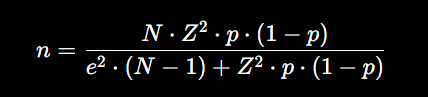

Onde:

n = tamanho da amostra necessária  
N = tamanho da população (100.000 clientes)  
Z = valor da distribuição normal para o nível de confiança  
p = proporção esperada (quando não sabemos, usamos 0,5)  
e = margem de erro

Valores do problema:

População -> N=100000

Confiança -> 95%

Então -> Z=1,96

Como não sabemos a proporção real de cancelamento -> p=0,5

In [114]:
# caso 1, margem de erro de 2%, ou seja, e=0,02
import math

N = 100000
Z = 1.96
p = 0.5
e = 0.02

n = (N * (Z**2) * p * (1-p)) / ((e**2)*(N-1) + (Z**2)*p*(1-p))

print(math.ceil(n))

2345


Para uma população de 100.000 clientes, seriam necessários aproximadamente 2.331 clientes para obter 95% de confiança com margem de erro de 2%.

In [115]:
# caso 2, margem de erro de 10%, ou seja, e=0,10

N = 100000
Z = 1.96
p = 0.5
e = 0.10

n = (N * (Z**2) * p * (1-p)) / ((e**2)*(N-1) + (Z**2)*p*(1-p))

print(math.ceil(n))

96


Com uma margem de erro de 10%, seriam necessários aproximadamente 96 clientes.

In [116]:
print(f'Linhas e colunas do dataframe: {df.shape}')
# temos 200 linhas e 9 colunas
# 200 clientes

Linhas e colunas do dataframe: (200, 9)


| Margem de erro | Amostra necessária | Base suficiente? |
| -------------- | ------------------ | ---------------- |
| 2%             | 2331 clientes      | ❌ Não            |
| 10%            | 96 clientes        | ✅ Sim            |


A base disponibilizada contém 200 clientes, sendo comparada a uma população hipotética de 100.000 clientes. Para um nível de confiança de 95% e margem de erro de 2%, seriam necessários 2.331 registros, portanto a amostra disponível não é suficiente para garantir esse nível de precisão. Entretanto, considerando uma margem de erro de 10%, o tamanho mínimo necessário seria de 96 clientes, tornando a base disponível suficiente para análises com menor precisão.